# Project Title : **Digital Signals**


# ML_Baseline _Models

**Input:** `df_all_clean.csv`  
**output:** 
* Predicted class(low/moderate/high)Risk
* Probability score per class

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')



from sklearn.model_selection import  GridSearchCV, ParameterGrid, StratifiedKFold, cross_validate
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
import shap



In [2]:
seed = 42

import os, random, numpy as np

os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
random.seed(seed)

## 2. Load Data and recheck

In [3]:
df=pd.read_csv("C:/Users/ASUS/Desktop/Fac/Digital_Signals/data/processed/df_all_clean.csv")
df.head()

,text,target,risk_level,text_lemmatized
0,just as the the title says i feel like one is ...,depression,high_risk,just a the the title say i feel like one is hy...
1,a blackened sky encroached tugging behind it m...,depression,high_risk,a blackened sky encroached tugging behind it m...
2,it gives you insomnia which in turn makes your...,depression,high_risk,it give you insomnia which in turn make your d...
3,hello all im a new submitter to this channel i...,normal,low_risk,hello all im a new submitter to this channel i...
4,thank god the cb is over for eid,normal,low_risk,thank god the cb is over for eid


In [4]:
df.shape

(11917, 4)

In [5]:
df.isnull().sum()

text               0
target             0
risk_level         0
text_lemmatized    0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df.columns

Index(['text', 'target', 'risk_level', 'text_lemmatized'], dtype='object')

## 3. Splitting Data

Target distribution

In [ ]:
df['risk_level'].value_counts()

high_risk        6301
low_risk         3590
moderate_risk    2026
Name: risk_level, dtype: int64

In [9]:
#splitting features and target
X = df['text_lemmatized']
y= df['risk_level']


In [10]:
#test & train data 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f'\nTrain: {len(X_train)} | Test: {len(X_test)}')
print('Test class distribution:')
print(y_test.value_counts())


Train: 9533 | Test: 2384
Test class distribution:
high_risk        1261
low_risk          718
moderate_risk     405
Name: risk_level, dtype: int64


-------->We have an Imbalanced Dataset

## 4. Model 1 : Logistic Regression

In [ ]:
lr_param_grid = {
    'tfidf__max_features': [5000, 10000, 15000],
    'tfidf__ngram_range':  [(1,1), (1,2)],
    'clf__C':              [0.1, 1, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [ ]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, stop_words='english')),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])



grid = GridSearchCV(
    pipeline,
    lr_param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid.fit(X_train, y_train)

print("Best params: ", grid.best_params_)
print(f"Best CV F1: {grid.best_score_:.4f}")

best_lr = grid.best_estimator_


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params:  {'clf__C': 10, 'tfidf__max_features': 15000, 'tfidf__ngram_range': (1, 2)}
Best CV F1: 0.8259


In [13]:
# Predictions
y_pred_lr = best_lr.predict(X_test)
y_proba_lr = best_lr.predict_proba(X_test)

# Metrics
final_f1  = f1_score(y_test, y_pred_lr, average='macro')
final_auc = roc_auc_score(y_test, y_proba_lr, multi_class='ovr', average='macro')

print("="*50)
print("LOGISTIC REGRESSION — Final Test Results")
print("="*50)
print(f"Macro F1  : {final_f1:.4f}")
print(f"ROC-AUC   : {final_auc:.4f}")
print(f"\nBest params: {grid.best_params_}")

LOGISTIC REGRESSION — Final Test Results
Macro F1  : 0.8343
ROC-AUC   : 0.9557

Best params: {'clf__C': 10, 'tfidf__max_features': 15000, 'tfidf__ngram_range': (1, 2)}


In [14]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))


Classification Report:
               precision    recall  f1-score   support

    high_risk       0.90      0.87      0.89      1261
     low_risk       0.83      0.89      0.86       718
moderate_risk       0.76      0.75      0.75       405

     accuracy                           0.86      2384
    macro avg       0.83      0.84      0.83      2384
 weighted avg       0.86      0.86      0.86      2384



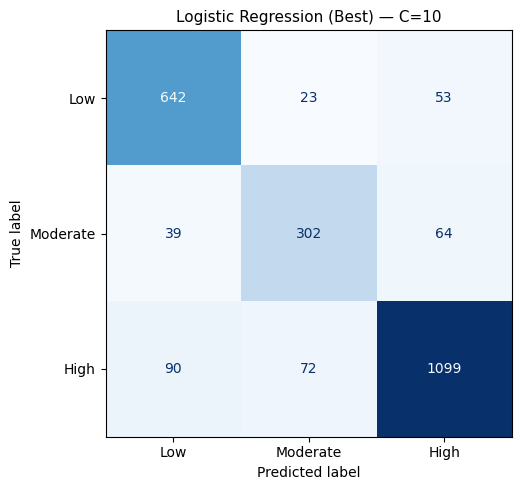

In [15]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    labels=['low_risk', 'moderate_risk', 'high_risk'],
    display_labels=['Low', 'Moderate', 'High'],
    cmap='Blues', ax=ax, colorbar=False
)
ax.set_title(f'Logistic Regression (Best) — C={grid.best_params_["clf__C"]}', fontsize=11)
plt.tight_layout()
plt.show()

## 5. Model 2 : Linear SVM

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

# Hyperparameters grid for SVM
svm_param_grid = {
    'tfidf__max_features': [5000, 10000, 15000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'clf__C': [0.1, 1, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [17]:
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, stop_words='english')),
    ('clf', LinearSVC(class_weight='balanced', max_iter=1000, random_state=42))
])

grid_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_svm.fit(X_train, y_train)

print("Best params (SVM):", grid_svm.best_params_)
print(f"Best CV Macro F1 (SVM): {grid_svm.best_score_:.4f}")

best_svm = grid_svm.best_estimator_



Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params (SVM): {'clf__C': 1, 'tfidf__max_features': 15000, 'tfidf__ngram_range': (1, 2)}
Best CV Macro F1 (SVM): 0.8234


In [18]:
y_pred_svm = best_svm.predict(X_test)
final_f1 = f1_score(y_test, y_pred_svm, average='macro')


In [19]:
# raw  SVM for F1
y_pred_svm = best_svm.predict(X_test)

#calibrated SVM for ROC-AUC
calibrated_svm = CalibratedClassifierCV(best_svm, method='sigmoid', cv='prefit') 
calibrated_svm.fit(X_train, y_train)
y_proba_svm = calibrated_svm.predict_proba(X_test)

final_f1 = f1_score(y_test, y_pred_svm, average='macro')
final_auc = roc_auc_score(y_test, y_proba_svm, multi_class='ovr', average='macro')

In [20]:
print("="*50)
print("SVM — Final Test Results")
print("="*50)
print(f"Macro F1 on test set: {final_f1:.4f}")
print(f'ROC-AUC (ovr): {final_auc:.4f}')
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

SVM — Final Test Results
Macro F1 on test set: 0.8294
ROC-AUC (ovr): 0.9478

Classification Report:
                precision    recall  f1-score   support

    high_risk       0.90      0.89      0.89      1261
     low_risk       0.82      0.89      0.86       718
moderate_risk       0.79      0.70      0.74       405

     accuracy                           0.86      2384
    macro avg       0.84      0.83      0.83      2384
 weighted avg       0.86      0.86      0.86      2384



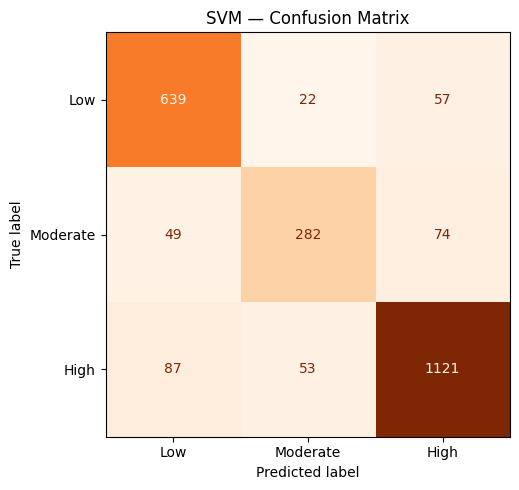

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm,
    labels=['low_risk', 'moderate_risk', 'high_risk'],
    display_labels=['Low', 'Moderate', 'High'],
    cmap='Oranges', ax=ax, colorbar=False
)
ax.set_title('SVM — Confusion Matrix', fontsize=12)
plt.tight_layout()
plt.show()

LR is better than SVM since he predicts less false negative high risk cases which can have critical impacts based on our project concept

## 6. Model 3 : Random Forest

trying different parameters

In [ ]:
rf_param_grid = {
    'tfidf__max_features': [5000, 10000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [23]:
rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, stop_words='english')),
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])


grid_rf = GridSearchCV(
    rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    refit=True
)


grid_rf.fit(X_train, y_train)

print("="*50)
print("RANDOM FOREST — Best Hyperparameters")
print("="*50)
print(grid_rf.best_params_)
print(f"Best CV Macro F1: {grid_rf.best_score_:.4f}")



Fitting 5 folds for each of 48 candidates, totalling 240 fits
RANDOM FOREST — Best Hyperparameters
{'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 200, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 2)}
Best CV Macro F1: 0.7625


In [24]:
# Evaluate on test set
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)

final_f1  = f1_score(y_test, y_pred_rf, average='macro')
final_auc = roc_auc_score(y_test, y_proba_rf, multi_class='ovr', average='macro')

print("="*50)
print("RANDOM FOREST — Final Test Results")
print("="*50)
print(f"Macro F1  : {final_f1:.4f}")
print(f"ROC-AUC   : {final_auc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST — Final Test Results
Macro F1  : 0.7641
ROC-AUC   : 0.9374

Classification Report:

               precision    recall  f1-score   support

    high_risk       0.80      0.90      0.85      1261
     low_risk       0.81      0.85      0.83       718
moderate_risk       0.87      0.47      0.61       405

     accuracy                           0.81      2384
    macro avg       0.83      0.74      0.76      2384
 weighted avg       0.82      0.81      0.80      2384



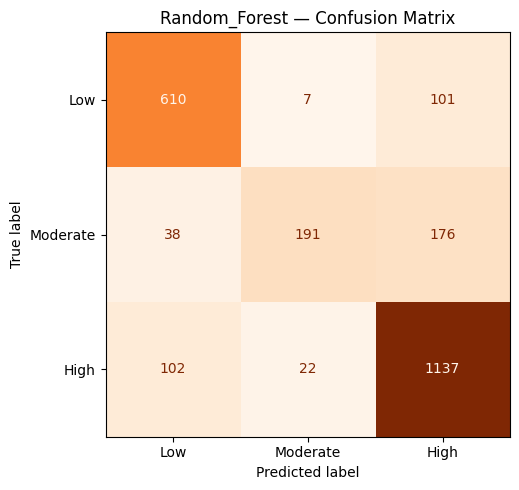

In [25]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    labels=['low_risk', 'moderate_risk', 'high_risk'],
    display_labels=['Low', 'Moderate', 'High'],
    cmap='Oranges', ax=ax, colorbar=False
)
ax.set_title('Random_Forest — Confusion Matrix', fontsize=12)
plt.tight_layout()
plt.show()

## Model Comparison

In [26]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Linear SVM', 'Random Forest'],
    'Macro F1': [
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_svm, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro')
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_proba_lr, multi_class='ovr', average='macro'),
        roc_auc_score(y_test, y_proba_svm, multi_class='ovr', average='macro'),
        roc_auc_score(y_test, y_proba_rf, multi_class='ovr', average='macro')
    ]
}).sort_values('Macro F1', ascending=False).reset_index(drop=True)

print(results.to_string(index=False))

              Model  Macro F1  ROC-AUC
Logistic Regression  0.834268 0.955721
         Linear SVM  0.829438 0.947758
      Random Forest  0.764119 0.937383


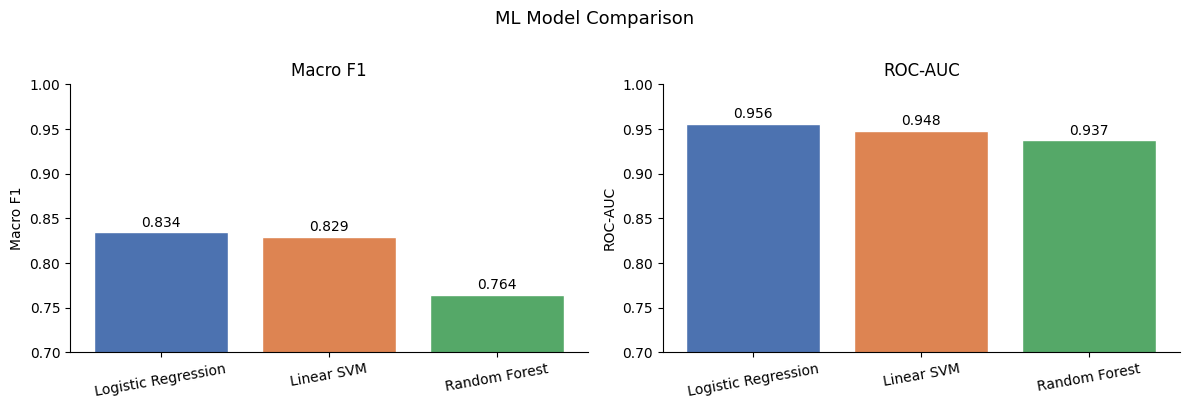

In [27]:
# ── Bar chart ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, metric in zip(axes, ['Macro F1', 'ROC-AUC']):
    bars = ax.bar(results['Model'], results[metric], color=colors, edgecolor='white')
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)
    ax.set_ylim(0.7, 1.0)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('ML Model Comparison', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

comparision btw LR & SVM based on critical misses

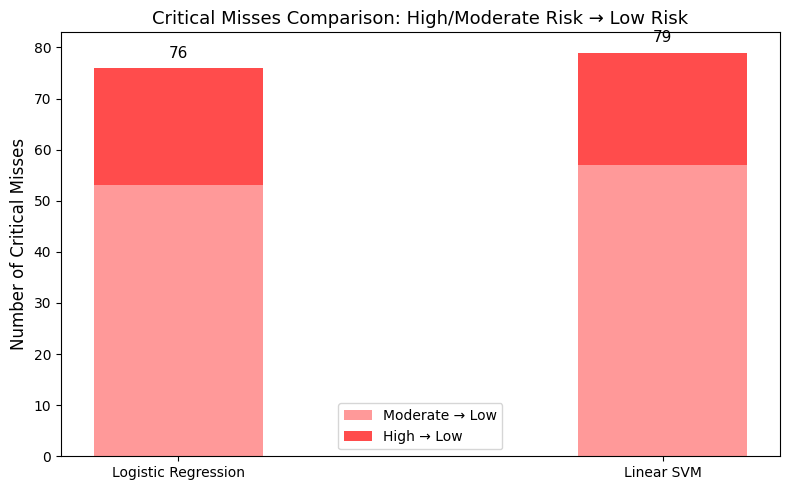

In [ ]:
# Critical misses (High + Moderate predicted as Low)
models = ['Logistic Regression', 'Linear SVM']
 miss_mod_to_low= [23, 22]     
 
miss_high_to_low= [53, 57]       

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))

# Stacked bars
ax.bar(x, miss_mod_to_low, width, label='Moderate → Low', color='#FF9999')
ax.bar(x, miss_high_to_low, width, bottom=miss_mod_to_low, label='High → Low', color='#FF4C4C')


ax.set_ylabel('Number of Critical Misses', fontsize=12)
ax.set_title('Critical Misses Comparison: High/Moderate Risk → Low Risk', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# values 
for i in range(len(models)):
    total = miss_mod_to_low[i] + miss_high_to_low[i]
    ax.text(i, total + 2, str(total), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

>----> As we are treating a health case so making fewer missed critical misses matter that why LR is considered as the best model 

## 8. SHAP Explainability (Logistic Regression)

**Model Choice & Explainability**

LR achieved the best performance in terms of safety , we will also used  **for model interpretability**.

**Why Logistic Regression for Explainability**
* Easier to interpret compared to SVM
* Compatible with SHAP for feature-level explanations

**What is SHAP :**

* SHAP (SHapley Additive exPlanations) is a method **used to explain model predictions** by assigning an **importance value to each feature**.

In our case:

* Each word gets a contribution score
* Shows how much each word influences the prediction toward:
    * Low risk
    * Moderate risk
    * High risk

**Why SHAP is Important**
* Provides transparency in a sensitive domain (mental health)
* Helps identify key risk-indicating words
* Supports ethical AI by making predictions understandable

>At the end our model will not appear like a **Black Box**

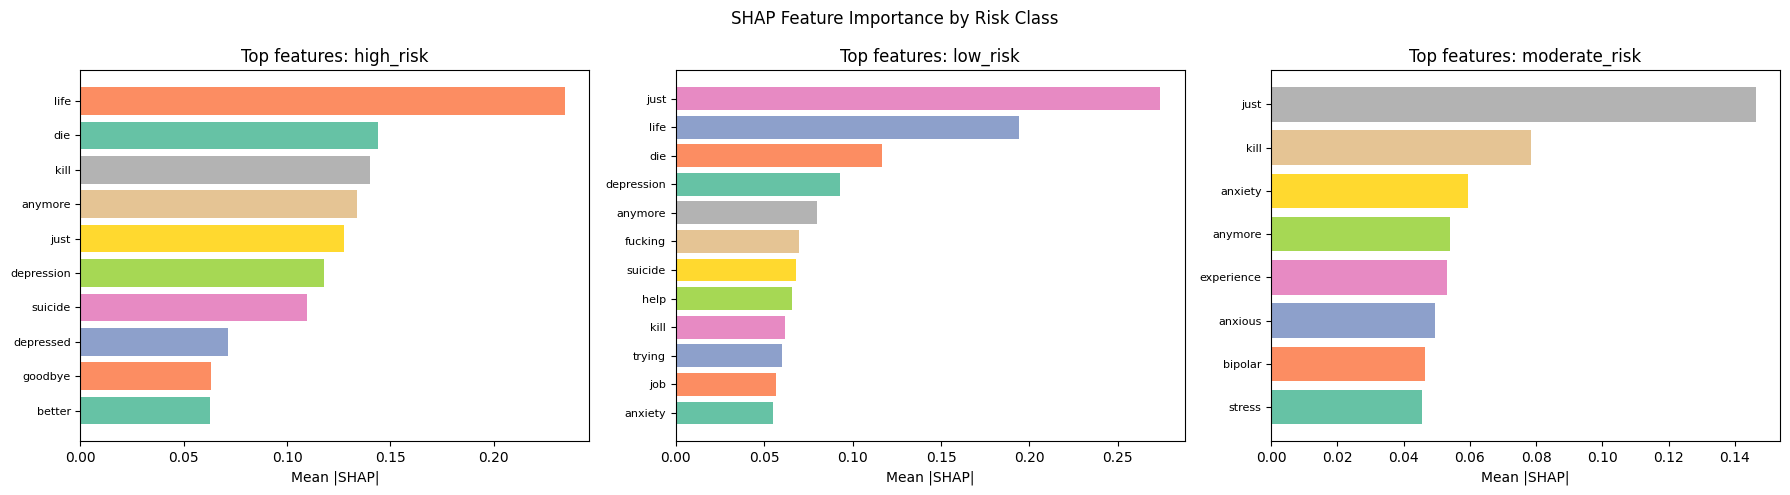

In [29]:
# Extract TF-IDF + Logistic Regression
vectorizer = best_lr.named_steps['tfidf']
clf = best_lr.named_steps['clf']

# Transform a sample of test data 
X_sample = X_test.head(200)
X_test_tfidf = vectorizer.transform(X_sample)

# SHAP Explainer
explainer = shap.LinearExplainer(clf, X_test_tfidf)
shap_values = explainer.shap_values(X_test_tfidf)

feature_names = vectorizer.get_feature_names_out()
classes = clf.classes_


custom_stopwords = {'im','dont' 'just', 'wa', 'ive', 'dont', 'ha', 'get','want', 'really', 'feel', 'feeling'}


# Plot top features per class
fig, axes = plt.subplots(1, len(classes), figsize=(18, 5))

for i, (cls, ax) in enumerate(zip(classes, axes)):
    
    
    if isinstance(shap_values, list):
        sv = shap_values[i]
    else:
        sv = shap_values[:, :, i]

    mean_abs = np.abs(sv).mean(axis=0)
    top_idx = np.argsort(mean_abs)[-15:]
    filtered_idx = [idx for idx in top_idx if feature_names[idx] not in custom_stopwords]

    ax.barh(
        feature_names[filtered_idx],
        mean_abs[filtered_idx],
        color=sns.color_palette('Set2', len(top_idx))
    )
    ax.set_title(f'Top features: {cls}')
    ax.set_xlabel('Mean |SHAP|')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('SHAP Feature Importance by Risk Class')
plt.tight_layout()
plt.show()

------------>removing some unmeaningful words for better interpretation

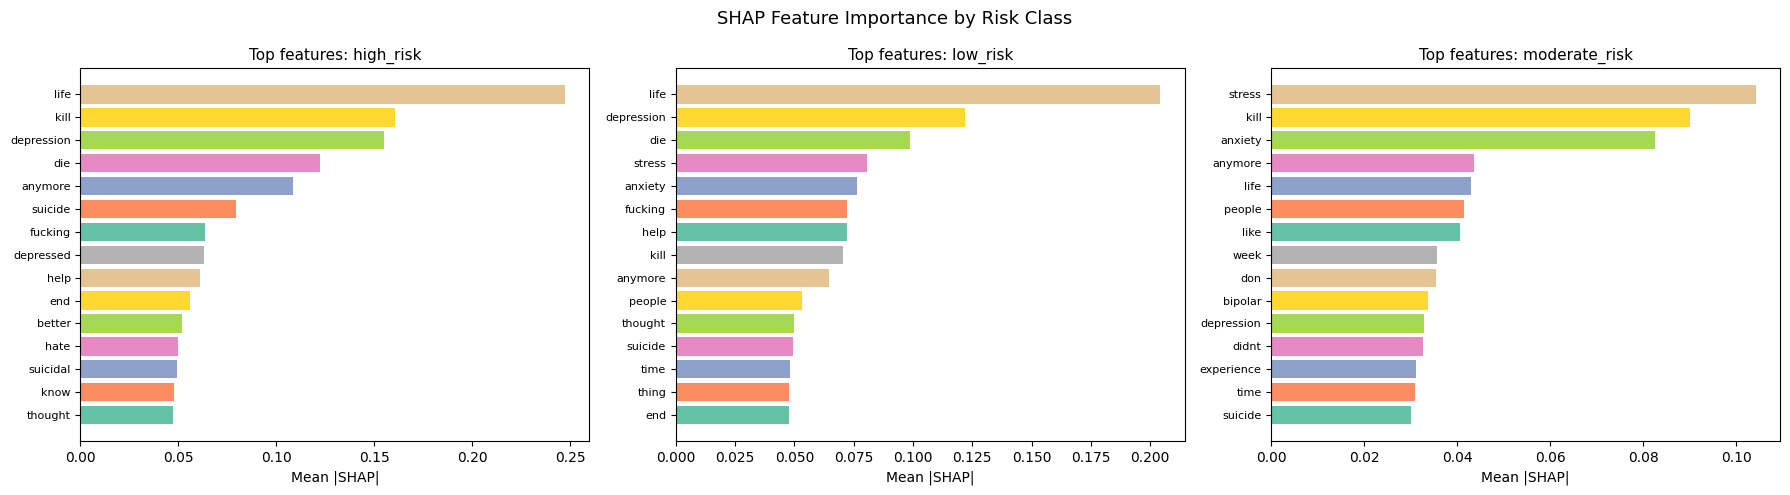

In [ ]:
custom_stopwords = {'im','dont','just','wa','ive','ha','get','want','really','feel','feeling'}

vectorizer = best_lr.named_steps['tfidf']
clf = best_lr.named_steps['clf']

X_sample = X_test.head(500)  
X_test_tfidf = vectorizer.transform(X_sample)

# we will use (interventional perturbation for better independence)
explainer = shap.LinearExplainer(clf, X_test_tfidf, feature_perturbation='interventional')
shap_values = explainer.shap_values(X_test_tfidf)

feature_names = vectorizer.get_feature_names_out()
classes = clf.classes_

#check if a token is meaningful and not a custom stopword
def is_meaningful(token):
    return len(token) > 2 and token.isalpha() and token.lower() not in custom_stopwords


meaningful_idx = [i for i, word in enumerate(feature_names) if is_meaningful(word)]
filtered_features = feature_names[meaningful_idx]

# Plot 
fig, axes = plt.subplots(1, len(classes), figsize=(18, 5))

for i, (cls, ax) in enumerate(zip(classes, axes)):
    
    sv = shap_values[i] if isinstance(shap_values, list) else shap_values[:, :, i]

    sv = sv[:, meaningful_idx]

    mean_abs = np.abs(sv).mean(axis=0)

    # Select top 15 features
    top_idx = np.argsort(mean_abs)[-15:]

    ax.barh(
        filtered_features[top_idx],
        mean_abs[top_idx],
        color=sns.color_palette('Set2', len(top_idx))
    )
    ax.set_title(f'Top features: {cls}', fontsize=11)
    ax.set_xlabel('Mean |SHAP|', fontsize=10)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('SHAP Feature Importance by Risk Class', fontsize=13)
plt.tight_layout()
plt.show()

#### Save our Best model : LR

In [31]:
import joblib
joblib.dump(best_lr,'C:/Users/ASUS/Desktop/Fac/Digital_Signals/notebooks/models/lr_best_pipeline.pkl')

['C:/Users/ASUS/Desktop/Fac/Digital_Signals/notebooks/models/lr_best_pipeline.pkl']

## Summary

we will try to  use dp models in order to minimise critical cases even more